# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [2]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

for model_name, model in base_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="f1_macro")
    baseline_results[model_name] = (scores.mean(), scores.std())  

# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [8]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                        ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001],
    'svm__kernel': ['rbf', 'linear']
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_grid_search = GridSearchCV(estimator=svm_pipe, param_grid=svm_param_grid, scoring='f1_macro', cv=5, n_jobs=-1)
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [13]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

results = pd.DataFrame(svm_grid_search.cv_results_)[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values('rank_test_score').head(10)

print(results.to_string(index=False))


                                                         params  mean_test_score  std_test_score  rank_test_score
       {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}         0.978633        0.017581                1
{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}         0.976215        0.015266                2
  {'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__kernel': 'linear'}         0.976215        0.015266                2
   {'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kernel': 'linear'}         0.976215        0.015266                2
     {'svm__C': 100, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}         0.976157        0.016975                5
      {'svm__C': 10, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}         0.971340        0.016281                6
     {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}         0.969357        0.019323                7
    {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}         0.969350        

## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [15]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    'n_estimators': randint(50, 500),                    
    'max_depth': randint(2, 20),               
    'min_samples_split': randint(2, 20),                       
    'max_features': ['sqrt', 'log2', 0.5]
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

rf_random_search = RandomizedSearchCV(estimator=base_models['RandomForest'], param_distributions=rf_param_dist, n_iter=50, cv=5, scoring='f1_macro', random_state=42, n_jobs=-1)
rf_random_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': 8, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 434}
Лучший CV F1: 0.9554


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [33]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!             ║
# ╚══════════════════════════════════════════════════════════════╝




all_models = {
    ('SVM baseline', base_models['SVM'].fit(X_train, y_train)), 
    ('RF baseline', base_models['RandomForest'].fit(X_train, y_train)),
    ('SVM Grid Search', svm_grid_search.best_estimator_), 
    ('RF Random Search', rf_random_search.best_estimator_)
}

for name, model in all_models:
    y_pred = model.predict(X_test)
    print(f"{name}  |  Test F1 = {f1_score(y_test, y_pred, average='macro'):.4f}")
    print(classification_report(y_test, y_pred))


# Заполните таблицу:
# | Модель                | CV F1 (mean±std) | Test F1 |
# |-----------------------|------------------|---------|
# | SVM baseline          |                  |         |
# | SVM Grid Search       |                  |         |
# | RF baseline           |                  |         |
# | RF Random Search      |                  |         |

RF Random Search  |  Test F1 = 0.9526
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

SVM Grid Search  |  Test F1 = 0.9812
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

RF baseline  |  Test F1 = 0.9526
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0

 | Модель                | CV F1 (mean±std) | Test F1 |
 |-----------------------|------------------|---------|
 | SVM baseline          |       0.9694 ± 0.0193           |    0.9812     |
 | SVM Grid Search       |       0.9786 ± 0.017581           |    0.9812     |
 | RF baseline           |       0.9504 ± 0.0255           |     0.9526    |
 | RF Random Search      |       0.9554           |    0.9526     |

## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

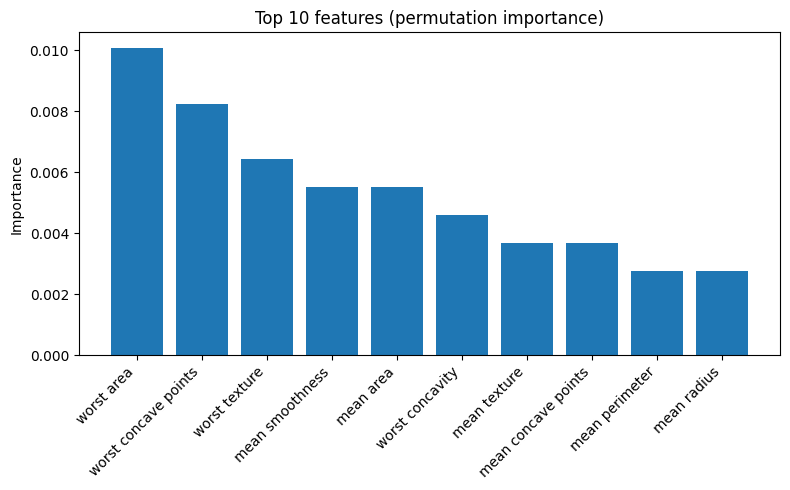

In [ ]:
from sklearn.inspection import permutation_importance

# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
pi_result = permutation_importance(best_rf, X_test, y_test, n_repeats=10, random_state=42, scoring='f1_macro')

sorted_idx = np.argsort(pi_result.importances_mean)[::-1][:10]

plt.figure(figsize=(8, 5))
plt.bar(range(10), pi_result.importances_mean[sorted_idx])
plt.xticks(range(10), X.columns[sorted_idx], rotation=45, ha='right')
plt.ylabel('Importance')
plt.title('permutation importance')
plt.tight_layout()
plt.show()
# Построим bar plot топ-10 признаков

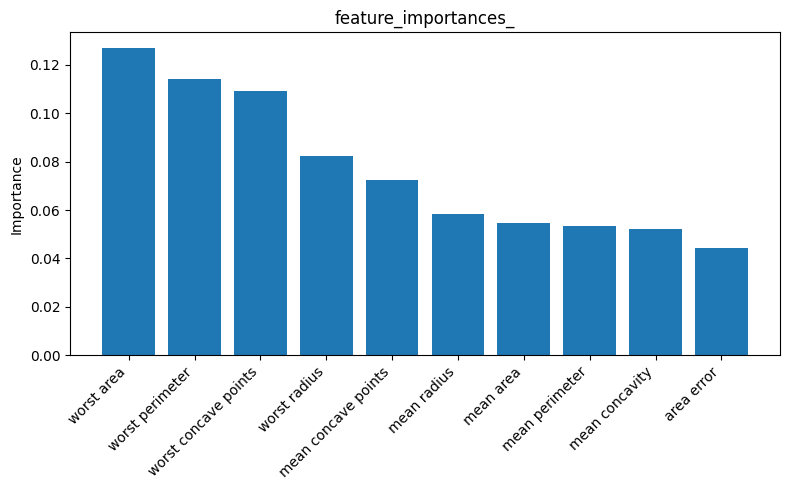

In [39]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝

sorted_idx = np.argsort(best_rf.feature_importances_)[::-1][:10]

plt.figure(figsize=(8, 5))
plt.bar(range(10), best_rf.feature_importances_[sorted_idx])
plt.xticks(range(10), X.columns[sorted_idx], rotation=45, ha='right')
plt.ylabel('Importance')
plt.title('feature_importances_')
plt.tight_layout()
plt.show()

# Вопрос для размышления:
# Некоторые признаки имеют высокий PI, но низкую встроенную важность,
# или наоборот. Что это может означать?

## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

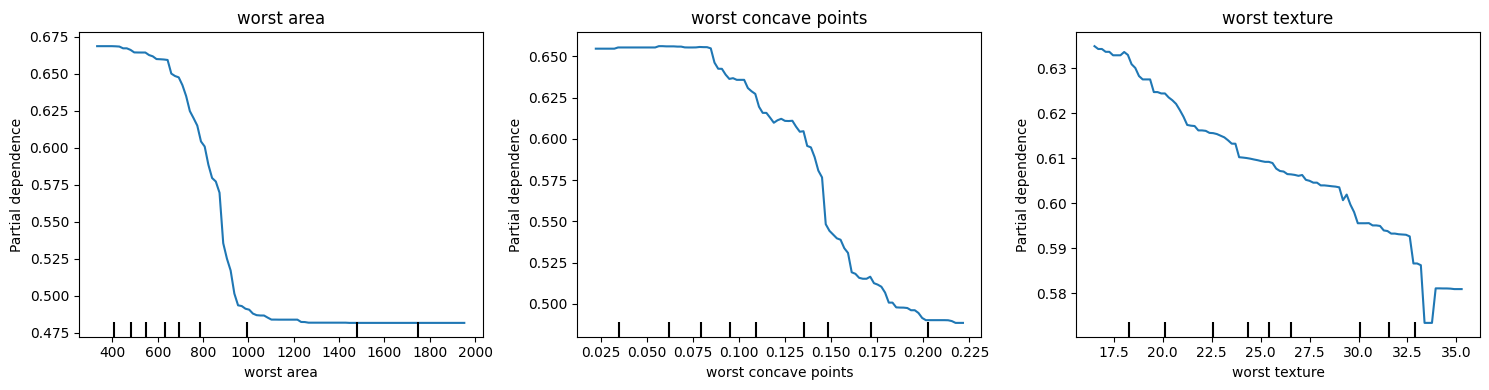

In [41]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝

# Определите индексы топ-3 признаков по PI
top3_idx = np.argsort(pi_result.importances_mean)[::-1][:3]

# Постройте PDP
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for i, feat_idx in enumerate(top3_idx):
    PartialDependenceDisplay.from_estimator(best_rf, X_test, [feat_idx], ax=ax[i], kind='average')
    ax[i].set_title(X.columns[feat_idx])
plt.tight_layout()
plt.show()

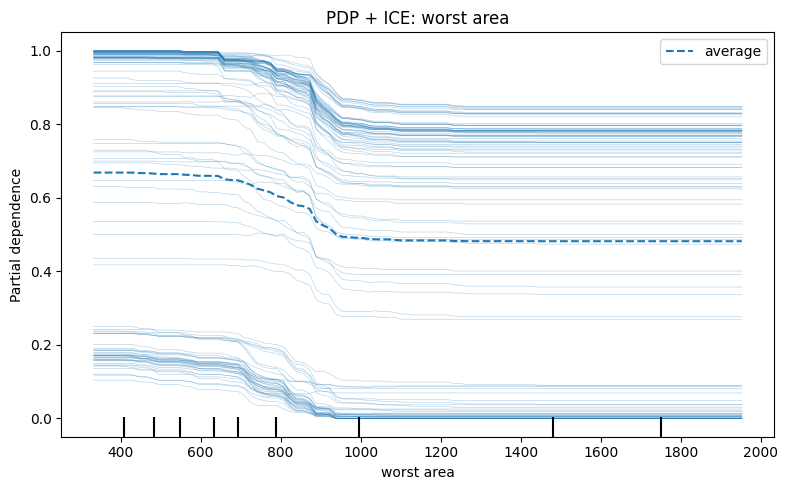

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)   ║
# ║  Вопрос: однороден ли эффект для всех объектов?              ║
# ╚══════════════════════════════════════════════════════════════╝

top1_idx = np.argsort(pi_result.importances_mean)[::-1][0]

fig, ax = plt.subplots(figsize=(8, 5))

PartialDependenceDisplay.from_estimator(
    best_rf, X_test, [top1_idx],
    kind='both',      
    ax=ax
)

ax.set_title(f'PDP + ICE: {X.columns[top1_idx]}')
plt.tight_layout()
plt.show()

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [45]:
# Установка SHAP (если не установлен)
# !pip install shap

import shap

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer(X_test)

print(shap_values.shape) 

(114, 30, 2)


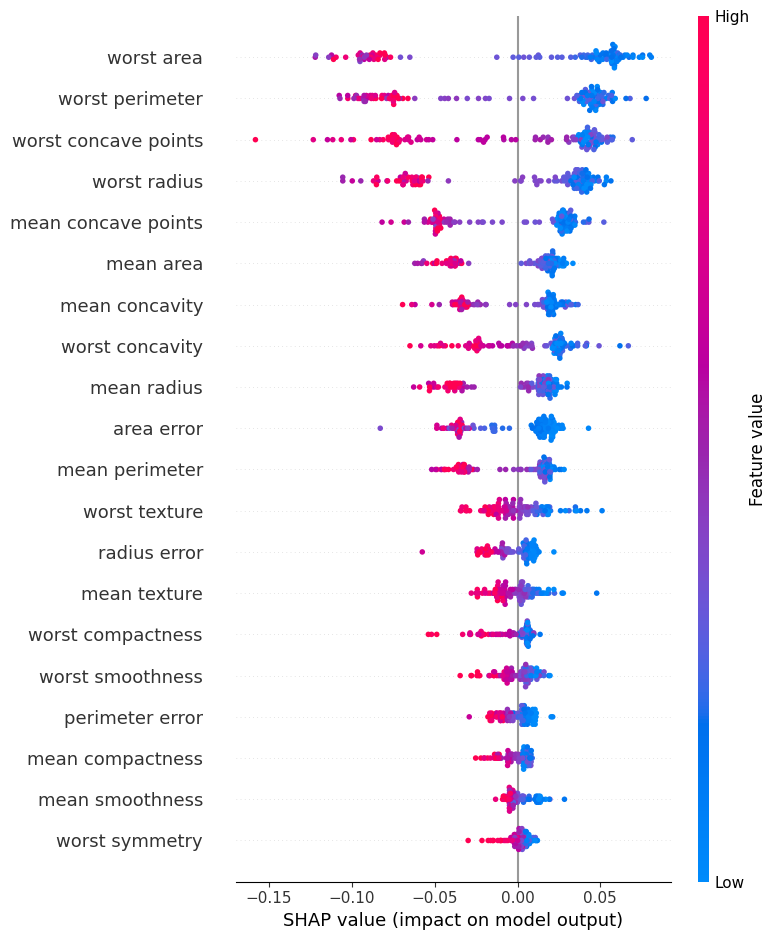

In [48]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
# ║  Для мультикласса используйте shap_values[1] (класс 1)       ║
# ║  Ответьте: какие признаки самые важные по SHAP?              ║
# ║  Совпадает ли с PI из шага 6?                                ║
# ╚══════════════════════════════════════════════════════════════╝

shap.summary_plot(shap_values[:, :, 1], X_test, feature_names=X.columns)

Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0


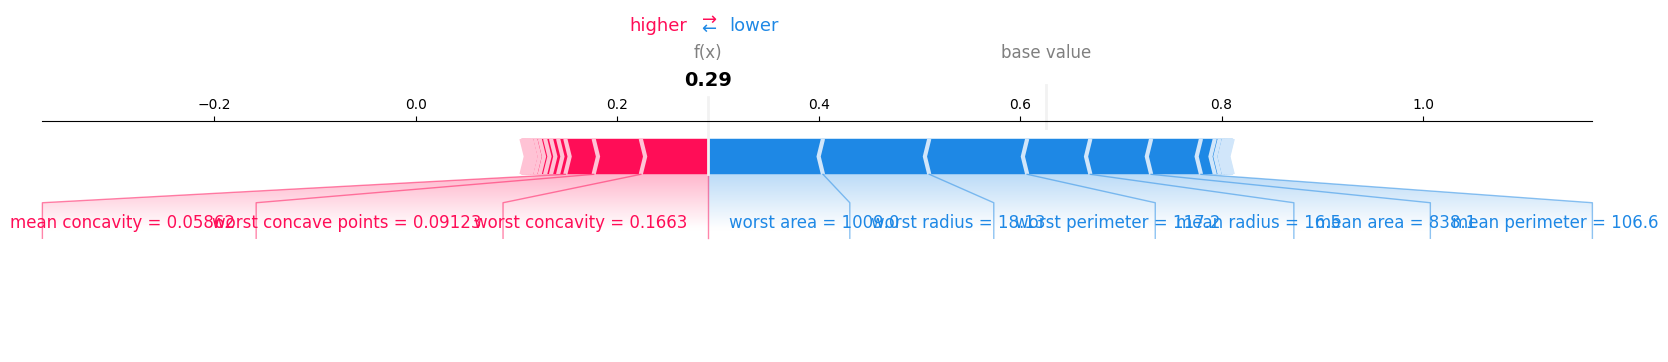

In [59]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
# ║  Какие признаки «виноваты» в ошибке?                         ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")

# YOUR CODE HERE
shap.force_plot(
    base_value=explainer.expected_value[1],
    shap_values=shap_values[errors[0], :, 1].values,  
    features=X_test.iloc[errors[0]],
    feature_names=(X.columns),
    matplotlib=True,
    figsize=(20, 3)
)

## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [60]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

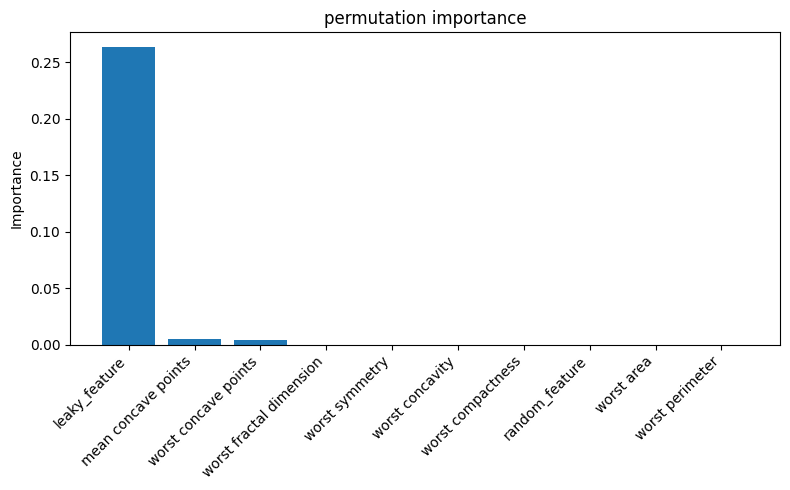

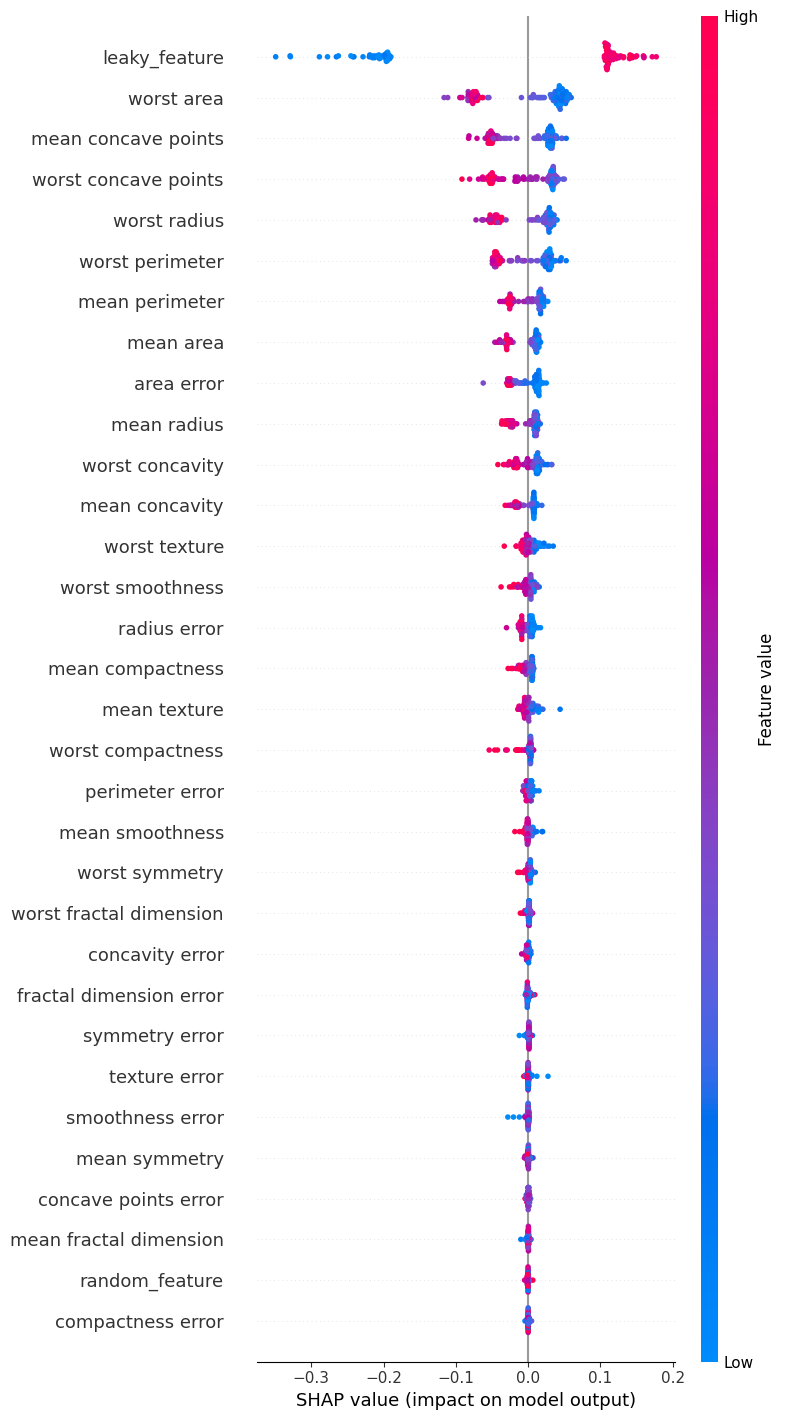

                    feature        PI  SHAP_mean_abs
0             leaky_feature  0.263342       0.158200
1       mean concave points  0.004689       0.038178
2      worst concave points  0.003752       0.035742
3               mean radius  0.000000       0.014903
4                 mean area  0.000000       0.017235
5           mean smoothness  0.000000       0.003176
6            mean perimeter  0.000000       0.018102
7              mean texture  0.000000       0.005813
8             mean symmetry  0.000000       0.000971
9    mean fractal dimension  0.000000       0.000713
10             radius error  0.000000       0.006199
11            texture error  0.000000       0.001329
12          perimeter error  0.000000       0.003975
13               area error  0.000000       0.016294
14         mean compactness  0.000000       0.006147
15           mean concavity  0.000000       0.011205
16        compactness error  0.000000       0.000621
17         smoothness error  0.000000       0.

In [74]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║
# ║     Почему метрика на тесте выросла?                         ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║
# ║  в) Как обнаружить random_feature как «шумовой»?             ║
# ╚══════════════════════════════════════════════════════════════╝

rf_ext = RandomForestClassifier(random_state=42)
rf_ext.fit(X_train_ext, y_train)

pi_ext = permutation_importance(rf_ext, X_test_ext, y_test,
                                n_repeats=10,
                                scoring='f1_macro',
                                random_state=42)

sorted_idx = np.argsort(pi_ext.importances_mean)[::-1][:10]

plt.figure(figsize=(8, 5))
plt.bar(range(10), pi_ext.importances_mean[sorted_idx])
plt.xticks(range(10), X_test_ext.columns[sorted_idx], rotation=45, ha='right')
plt.ylabel('Importance')
plt.title('permutation importance')
plt.tight_layout()
plt.show()

explainer_ext = shap.TreeExplainer(rf_ext)
shap_values_ext = explainer_ext(X_test_ext)
shap.summary_plot(shap_values_ext[:, :, 1], X_test_ext, feature_names=X_test_ext.columns, max_display=X_test_ext.shape[1])

pi_df = pd.DataFrame({'feature': X_test_ext.columns,'PI':pi_ext.importances_mean}).sort_values('PI',ascending=False)

explainer2_ext = shap.TreeExplainer(rf_ext)
sv = explainer2_ext.shap_values(X_test_ext)
shap_df = pd.DataFrame({'feature': X_test_ext.columns, 
                        'SHAP_mean_abs': np.abs(sv[:, :, 1]).mean(axis=0)}).sort_values('SHAP_mean_abs', ascending=False)
# Объединяем и смотрим на расхождения
combined = pi_df.merge(shap_df, on='feature')
print(combined)

print(f"PI shape: {pi_ext.importances.shape}")
print(f"SHAP shape: {shap_values_ext.shape}")

## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║
# ║  | Метод          | CV F1  | Test F1 | Выводы              | ║
# ║  |----------------|--------|---------|---------------------| ║
# ║  | SVM baseline   |        |         |                     | ║
# ║  | SVM Grid Search|        |         |                     | ║
# ║  | RF baseline    |        |         |                     | ║
# ║  | RF Rand Search |        |         |                     | ║
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели?                         ║
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему?                                       ║
# ║  3. Что было бы, если бы мы не использовали Pipeline?        ║
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте?     ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

 | Модель                | CV F1 (mean±std) | Test F1 |
 |-----------------------|------------------|---------|
 | SVM baseline          |       0.9694 ± 0.0193           |    0.9812     |
 | SVM Grid Search       |       0.9786 ± 0.017581           |    0.9812     |
 | RF baseline           |       0.9504 ± 0.0255           |     0.9526    |
 | RF Random Search      |       0.9554           |    0.9526     |

1. Метрика на тесте с кросс-валидацией не сильно улучшилась, а вот на тесте вообще одинаково
2. Первые 5 в точности совпали, а после есть пересечения. Вообще они по разному измеряются, но если выделять одну причину, то я бы сказал, что скоррелированность влияет на PI и не влияет на SHAP
3. Мы его использовали только в начале с ЛогРегом для того чтобы удобней было масштабировать признаки
4. Наверное, чтобы показывать на какие признаки модель больше опирается при выборе

## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

In [ ]:
# !pip install optuna

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ╔══════════════════════════════════════════════════════════════╗
# ║  БОНУС: Реализуйте objective-функцию для Optuna              ║
# ║  Используйте те же параметры, что в Random Search            ║
# ║  Запустите study.optimize с n_trials=50                      ║
# ║                                                              ║
# ║  Постройте график сходимости:                                ║
# ║  plt.plot(range(n_trials), best_values_over_time)            ║
# ║  Сравните кривые Optuna и Random Search (если логировали)    ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

def objective(trial):
    # YOUR CODE HERE
    pass

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)
# print(f"Лучший результат Optuna: {study.best_value:.4f}")
# print(f"Лучшие параметры: {study.best_params}")